# Detekcija anomalija u financijskim transakcijama: duboki autoenkoder

Ova bilježnica implementira i evaluira duboki autoenkoder (engl. *Autoencoder*) za detekciju prijevarnih transakcija, korištenjem skupa podataka Credit Card Fraud Detection (ULB, Kaggle) te biblioteke Keras/TensorFlow.

Struktura prati poglavlje 4.5. završnog rada Izrada prototipa sustava za detekciju anomalija u financijskim sustavima u stvarnom vremenu primjenom metoda strojnog učenja.

Podatkovni skup dijeli se kronološki, identično kao u isolation_forest.ipynb: skup za učenje (63 %), validacijski skup (7 %) i testni skup (30 %). Prag odlučivanja određuje se na validacijskom skupu; testni skup koristi se samo jednom, za konačnu evaluaciju.



In [ ]:
#!pip install -q kagglehub scikit-learn pandas matplotlib seaborn
!pip install -q tensorflow

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score, confusion_matrix,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## 1. Učitavanje podataka

In [ ]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(f"{path}/creditcard.csv")
print(df.shape)
df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.
(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Predobrada i podjela podataka

Kao i kod algoritma izolacijskih stabala, kronološka podjela na tri skupa, potom RobustScaler prilagođen isključivo na skupu za učenje (*Time* i *Amount*).

Ključna razlika: trening skup sadrži isključivo legitimne transakcije (Class = 0), u skladu s polunadziranim pristupom (autoenkoder uči rekonstruirati samo normalno ponašanje), pa transakcije koje ne uspije vjerno rekonstruirati tretiramo kao potencijalne anomalije.

Unutar skupa za učenje dodatno se izdvaja mali dio legitimnih transakcija (10 %) isključivo za potrebe ranog zaustavljanja tijekom treniranja (engl. *early stopping*). Ovo je odvojeno od službenog validacijskog skupa (7 % cjelokupnog skupa), koji se koristi za određivanje praga odlučivanja, ne za samo treniranje.

In [ ]:
n = len(df)
train_end = int(n * 0.63)
val_end = int(n * 0.70)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

amount_scaler = RobustScaler()
train_df['Amount_scaled'] = amount_scaler.fit_transform(train_df[['Amount']])
val_df['Amount_scaled'] = amount_scaler.transform(val_df[['Amount']])
test_df['Amount_scaled'] = amount_scaler.transform(test_df[['Amount']])

time_scaler = RobustScaler()
train_df['Time_scaled'] = time_scaler.fit_transform(train_df[['Time']])
val_df['Time_scaled'] = time_scaler.transform(val_df[['Time']])
test_df['Time_scaled'] = time_scaler.transform(test_df[['Time']])

feature_cols = [c for c in df.columns if c.startswith('V')] + ['Amount_scaled', 'Time_scaled']

# train only on legitimate transactions
X_train_normal = train_df[train_df['Class'] == 0][feature_cols].values

earlystop_split = int(len(X_train_normal) * 0.9)
X_fit = X_train_normal[:earlystop_split]
X_earlystop = X_train_normal[earlystop_split:]

X_val = val_df[feature_cols].values
y_val = val_df['Class'].values

X_test = test_df[feature_cols].values
y_test = test_df['Class'].values

print(f"Train (just legitimate): {X_fit.shape}")
print(f"Early stopping (just legitimate): {X_earlystop.shape}")
print(f"Validation (both classes): {X_val.shape}, Fraud Rate: {y_val.mean() * 100:.4f} %")
print(f"Test (both classes): {X_test.shape}, Fraud Rate: {y_test.mean() * 100:.4f} %")

Train (just legitimate): (161157, 30)
Early stopping (just legitimate): (17907, 30)
Validation (both classes): (19936, 30), Fraud Rate: 0.1003 %
Test (both classes): (85443, 30), Fraud Rate: 0.1264 %


## 3. Arhitektura autoenkodera

Simetrična arhitektura enkoder – usko grlo – dekoder. Ulazna dimenzija odgovara broju značajki (30: V1–V28, Amount_scaled, Time_scaled).

In [ ]:
input_dim = X_fit.shape[1]

autoencoder = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(20, activation='relu'),
    layers.Dense(14, activation='relu'),
    layers.Dense(8, activation='relu', name='bottleneck'),
    layers.Dense(14, activation='relu'),
    layers.Dense(20, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           294 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 14)             │           126 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │           630 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,090 (8.16 KB)

 Trainable params: 2,090 (8.16 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Treniranje

Epoch 1/50
630/630 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.7862 - val_loss: 0.7532
Epoch 2/50
630/630 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4477 - val_loss: 0.5898
Epoch 3/50
630/630 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3631 - val_loss: 0.5472
Epoch 4/50
630/630 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3349 - val_loss: 0.5193
Epoch 5/50
630/630 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3162 - val_loss: 0.4966
Epoch 6/50
630/630 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3014 - val_loss: 0.4854
Epoch 7/50
630/630 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2921 - val_loss: 0.4799
Epoch 8/50
630/630 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2859 - val_loss: 0.4751
Epoch 9/50
630/630 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2802 - val_loss: 0.4704
Epoch 10/50
630/630 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2752 - val_loss: 0.4660
Epoch 11/50
630/630 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2705 - val_loss: 0.4615
Epoch 12/50
630/630 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step

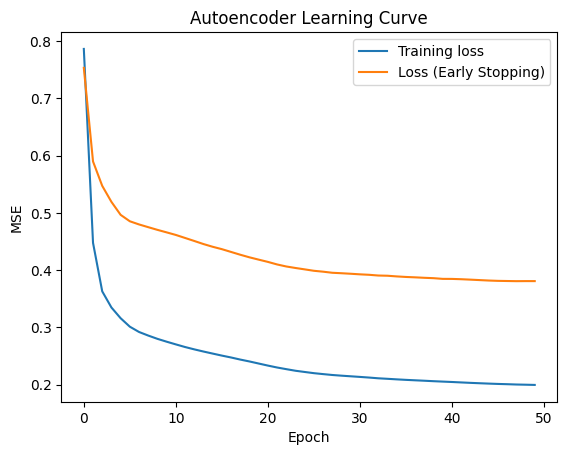

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = autoencoder.fit(
    X_fit, X_fit,
    validation_data=(X_earlystop, X_earlystop),
    epochs=50,
    batch_size=256,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Loss (Early Stopping)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Autoencoder Learning Curve')
plt.legend()
plt.show()

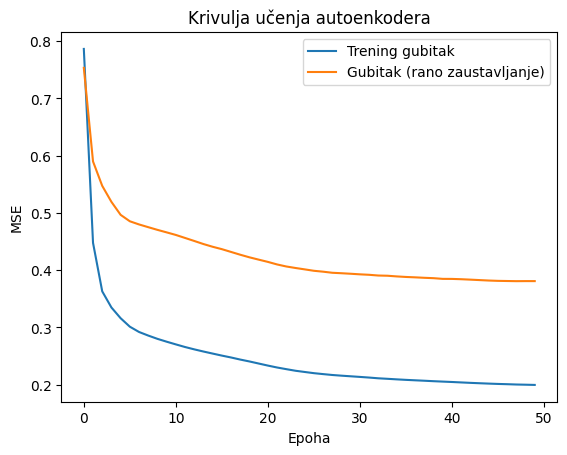

In [ ]:
plt.plot(history.history['loss'], label='Trening gubitak')
plt.plot(history.history['val_loss'], label='Gubitak (rano zaustavljanje)')
plt.xlabel('Epoha')
plt.ylabel('MSE')
plt.title('Krivulja učenja autoenkodera')
plt.legend()
plt.show()

## 5. Određivanje praga

Prag se određuje na temelju 99. percentila pogreške rekonstrukcije legitimnih transakcija u validacijskom skupu (7 %).

In [ ]:
X_val_normal = X_val[y_val == 0]
X_val_normal_pred = autoencoder.predict(X_val_normal, verbose=0)
val_normal_error = np.mean(np.square(X_val_normal - X_val_normal_pred), axis=1)

threshold = np.percentile(val_normal_error, 99)
print(f"Threshold (99. percentil, validation): {threshold:.4f}")

Threshold (99. percentil, validation): 1.4854


## 6. Evaluacija praga na validacijskom skupu

Prije prelaska na testni skup, provjerimo kako odabrani prag radi na cijelom validacijskom skupu (obje klase). Ovo je dijagnostički korak, ne konačan rezultat.

In [ ]:
X_val_pred = autoencoder.predict(X_val, verbose=0)
val_error = np.mean(np.square(X_val - X_val_pred), axis=1)
y_val_pred = (val_error > threshold).astype(int)

precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
roc_auc_val = roc_auc_score(y_val, val_error)
pr_auc_val = average_precision_score(y_val, val_error)

print("Results (validation):")
print(f"Precision: {precision_val:.4f}")
print(f"Recall: {recall_val:.4f}")
print(f"F1-score: {f1_val:.4f}")
print(f"ROC-AUC: {roc_auc_val:.4f}")
print(f"PR-AUC: {pr_auc_val:.4f}")

Results (validation):
Precision: 0.0610
Recall: 0.6500
F1-score: 0.1116
ROC-AUC: 0.9492
PR-AUC: 0.0686


## 7. Konačna evaluacija na testnom skupu

Prvi i jedini put da se testni skup koristi u ovoj bilježnici. Prag je fiksiran
iz koraka 5., na temelju validacijskog skupa.

Final results (test):
Precision: 0.1030
Recall: 0.7685
F1-score: 0.1816
ROC-AUC: 0.9306
PR-AUC: 0.1880


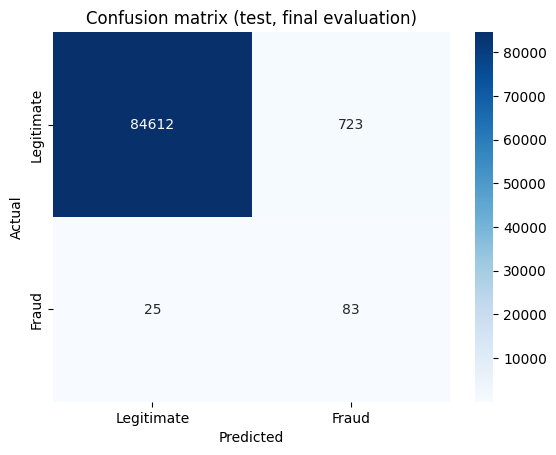

In [ ]:
X_test_pred = autoencoder.predict(X_test, verbose=0)
reconstruction_error = np.mean(np.square(X_test - X_test_pred), axis=1)
y_test_pred = (reconstruction_error > threshold).astype(int)

precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
roc_auc = roc_auc_score(y_test, reconstruction_error)
pr_auc = average_precision_score(y_test, reconstruction_error)

print("Final results (test):")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion matrix (test, final evaluation)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

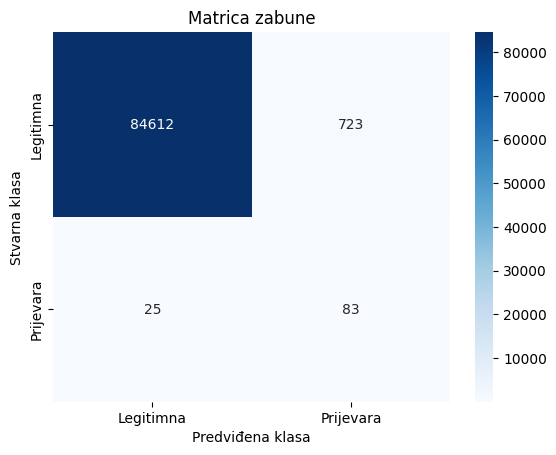

In [ ]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimna', 'Prijevara'], yticklabels=['Legitimna', 'Prijevara'])
plt.title('Matrica zabune')
plt.ylabel('Stvarna klasa')
plt.xlabel('Predviđena klasa')
plt.show()

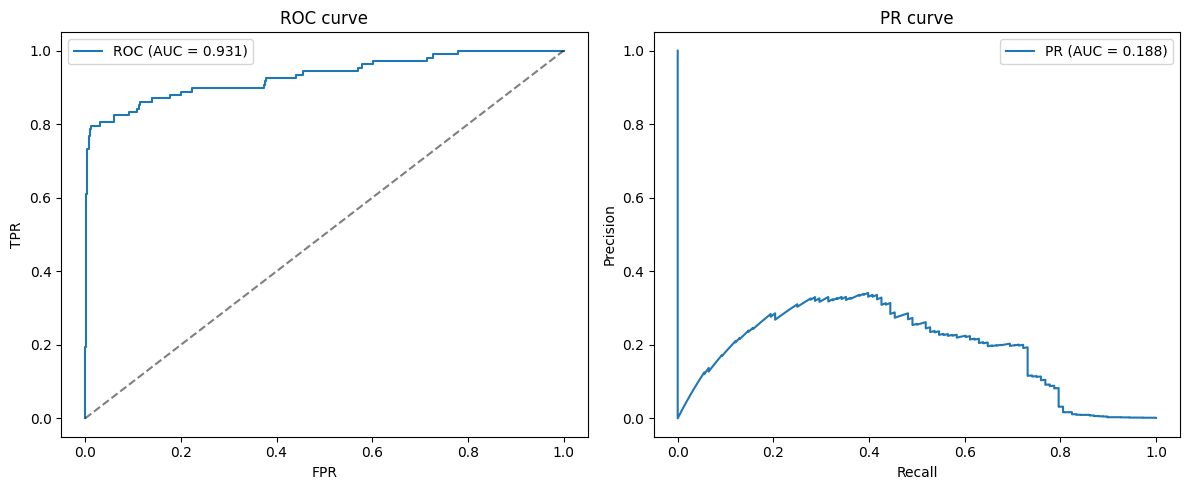

In [ ]:
fpr, tpr, _ = roc_curve(y_test, reconstruction_error)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, reconstruction_error)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC curve')
axes[0].legend()

axes[1].plot(rec_curve, prec_curve, label=f'PR (AUC = {pr_auc:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR curve')
axes[1].legend()
plt.tight_layout()
plt.show()

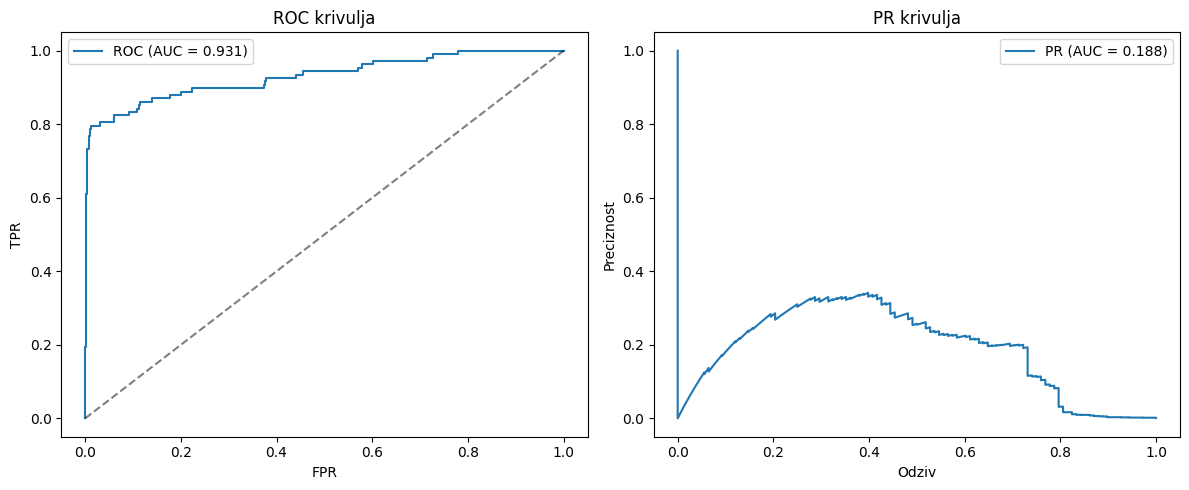

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC krivulja')
axes[0].legend()

axes[1].plot(rec_curve, prec_curve, label=f'PR (AUC = {pr_auc:.3f})')
axes[1].set_xlabel('Odziv')
axes[1].set_ylabel('Preciznost')
axes[1].set_title('PR krivulja')
axes[1].legend()
plt.tight_layout()
plt.show()

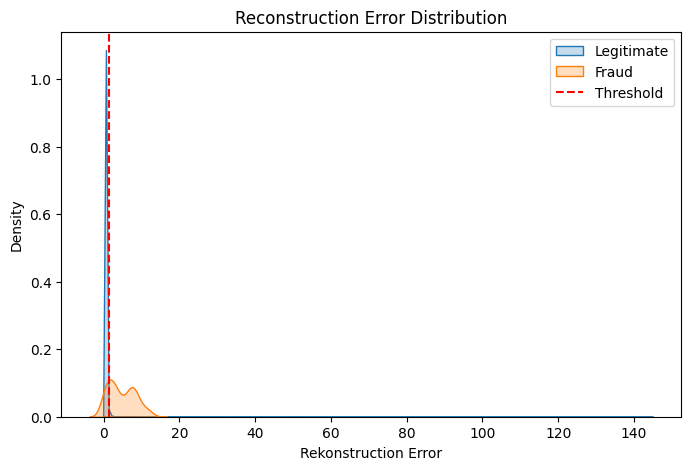

In [ ]:
plt.figure(figsize=(8, 5))
sns.kdeplot(reconstruction_error[y_test == 0], label='Legitimate', fill=True)
sns.kdeplot(reconstruction_error[y_test == 1], label='Fraud', fill=True)
plt.axvline(threshold, color='red', linestyle='--', label='Threshold')
plt.xlabel('Rekonstruction Error')
plt.title('Reconstruction Error Distribution')
plt.legend()
plt.show()

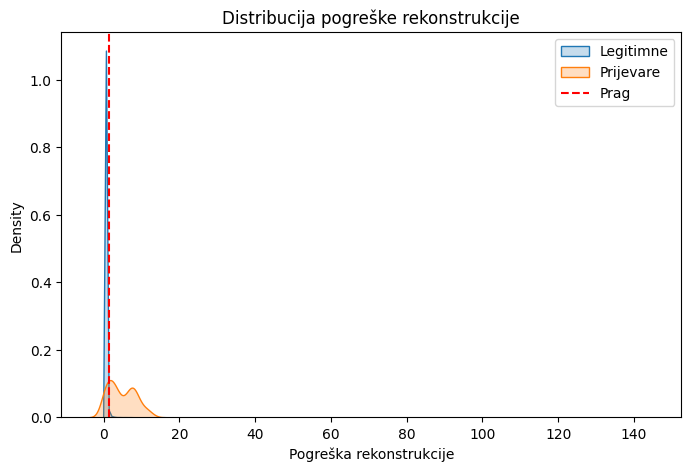

In [ ]:
plt.figure(figsize=(8, 5))
sns.kdeplot(reconstruction_error[y_test == 0], label='Legitimne', fill=True)
sns.kdeplot(reconstruction_error[y_test == 1], label='Prijevare', fill=True)
plt.axvline(threshold, color='red', linestyle='--', label='Prag')
plt.xlabel('Pogreška rekonstrukcije')
plt.title('Distribucija pogreške rekonstrukcije')
plt.legend()
plt.show()

## 8. Vizualizacija naučene reprezentacije (2D usko grlo)

Kako bismo intuitivno prikazali što autoenkoder uči, treniramo zaseban, ilustrativni autoenkoder s uskim grlom veličine samo 2 neurona (za razliku od stvarnog modela čije je usko grlo veličine 8). Ovo je isključivo u svrhu vizualizacije, odvojeno od modela korištenog za stvarnu evaluaciju. Nakon treniranja se primjenjuje samo enkoderski dio na testne podatke, čime se dobiva njihova 2D reprezentacija, prikazana u ravnini obojena prema stvarnoj klasi.

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


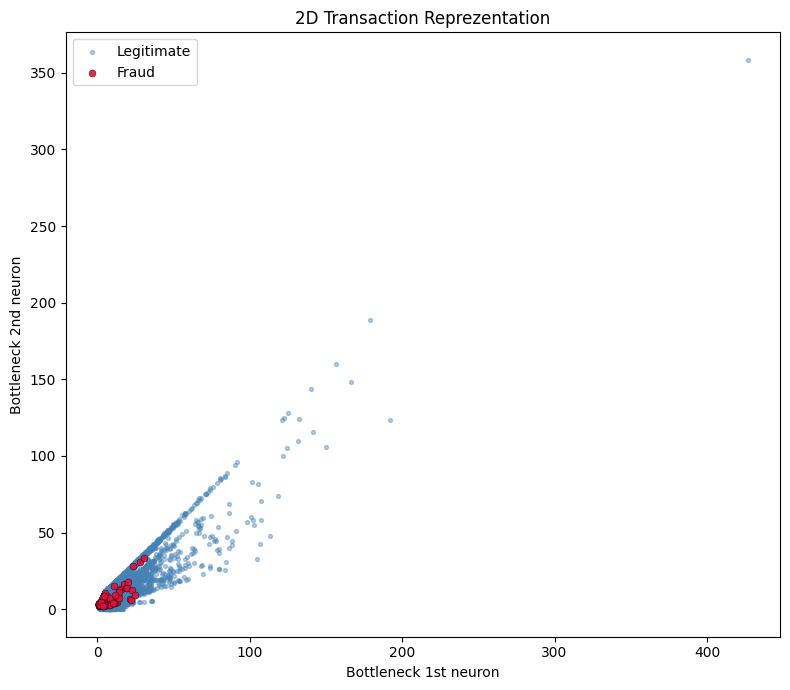

In [ ]:
encoder_viz = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(20, activation='relu'),
    layers.Dense(14, activation='relu'),
    layers.Dense(2, activation='relu', name='bottleneck_2d')
])
decoder_viz = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(14, activation='relu'),
    layers.Dense(20, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])
autoencoder_viz = keras.Sequential([encoder_viz, decoder_viz])
autoencoder_viz.compile(optimizer='adam', loss='mse')

autoencoder_viz.fit(
    X_fit, X_fit,
    validation_data=(X_earlystop, X_earlystop),
    epochs=30,
    batch_size=256,
    shuffle=True,
    verbose=0
)

X_test_2d = encoder_viz.predict(X_test)

plt.figure(figsize=(8, 7))
plt.scatter(X_test_2d[y_test == 0, 0], X_test_2d[y_test == 0, 1],
            c='steelblue', s=8, alpha=0.4, label='Legitimate')
plt.scatter(X_test_2d[y_test == 1, 0], X_test_2d[y_test == 1, 1],
            c='crimson', s=25, alpha=0.9, label='Fraud', edgecolors='k', linewidths=0.3)
plt.xlabel('Bottleneck 1st neuron')
plt.ylabel('Bottleneck 2nd neuron')
plt.title('2D Transaction Reprezentation')
plt.legend()
plt.tight_layout()
plt.show()

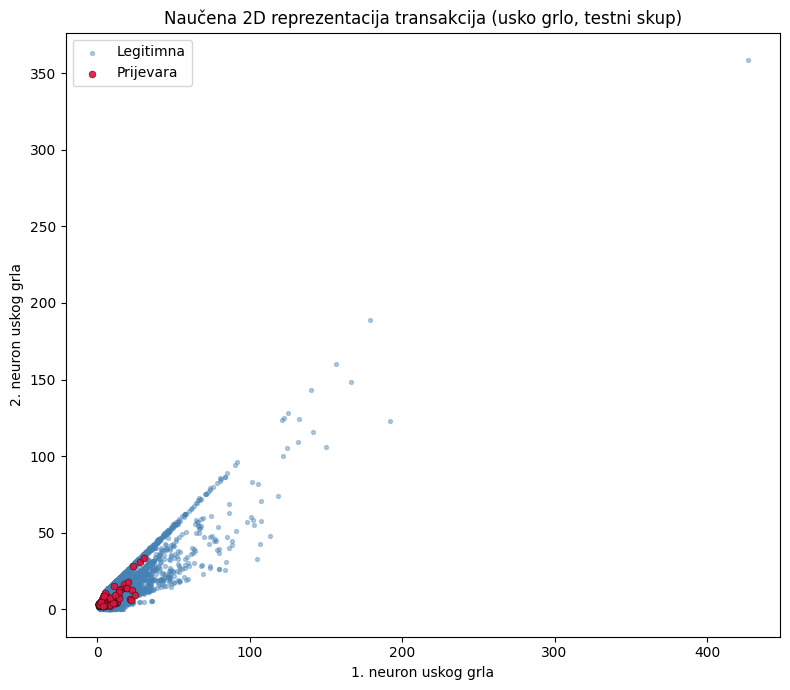

In [ ]:
plt.figure(figsize=(8, 7))
plt.scatter(X_test_2d[y_test == 0, 0], X_test_2d[y_test == 0, 1],
            c='steelblue', s=8, alpha=0.4, label='Legitimna')
plt.scatter(X_test_2d[y_test == 1, 0], X_test_2d[y_test == 1, 1],
            c='crimson', s=25, alpha=0.9, label='Prijevara', edgecolors='k', linewidths=0.3)
plt.xlabel('1. neuron uskog grla')
plt.ylabel('2. neuron uskog grla')
plt.title('Naučena 2D reprezentacija transakcija (usko grlo, testni skup)')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Spremanje modela

In [ ]:
autoencoder.save('autoencoder_model.keras')
joblib_note = f"Threshold: {threshold:.4f}"
with open('autoencoder_threshold.txt', 'w') as f:
    f.write(joblib_note)
print("Model saved.")
print(joblib_note)

Model saved.
Threshold: 1.4854
